# Ex No 9 - Develop a python program for Stereo Vision and Depth Estimation 


Stereo Vision & Depth Estimation
Resizing images to match size...


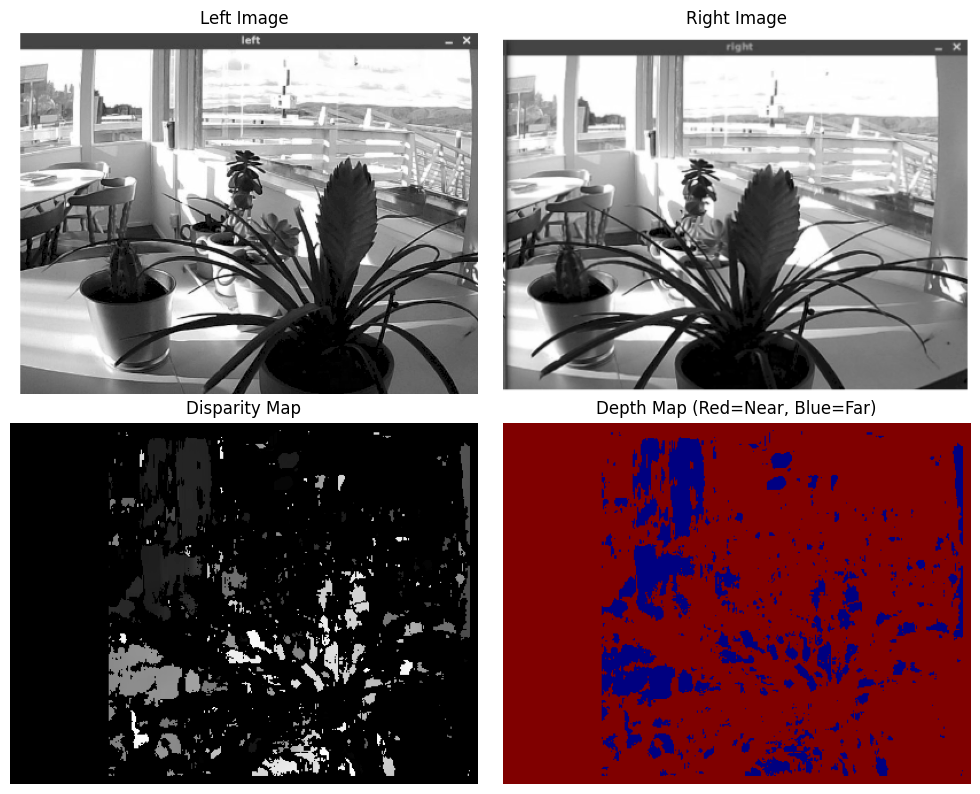

Experiment Completed Successfully


In [2]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# -------------------------------
# STEP 1: LOAD YOUR IMAGES
# -------------------------------
def load_images(left_path, right_path):
    left_img = cv2.imread(left_path, 0)   # 0 = grayscale
    right_img = cv2.imread(right_path, 0)

    if left_img is None or right_img is None:
        print("Error: Could not load images. Check file paths!")
        return None, None

    # Resize if sizes are different
    if left_img.shape != right_img.shape:
        print("Resizing images to match size...")
        right_img = cv2.resize(right_img, (left_img.shape[1], left_img.shape[0]))

    return left_img, right_img


# -------------------------------
# STEP 2: COMPUTE DISPARITY
# -------------------------------
def compute_disparity(left_img, right_img):
    stereo = cv2.StereoBM_create(numDisparities=16*5, blockSize=15)
    disparity = stereo.compute(left_img, right_img)
    return disparity


# -------------------------------
# STEP 3: COMPUTE DEPTH
# -------------------------------
def compute_depth(disparity):
    baseline = 120       # mm
    focal_length = 400   # pixels

    disparity = np.float32(disparity)
    disparity[disparity <= 0] = 0.1   # avoid division by zero

    depth = (baseline * focal_length) / disparity
    return depth


# -------------------------------
# STEP 4: VISUALIZATION
# -------------------------------
def visualize(left_img, right_img, disparity, depth):

    disp_norm = cv2.normalize(disparity, None, 0, 255, cv2.NORM_MINMAX)
    depth_norm = cv2.normalize(depth, None, 0, 255, cv2.NORM_MINMAX)

    depth_color = cv2.applyColorMap(depth_norm.astype(np.uint8), cv2.COLORMAP_JET)

    plt.figure(figsize=(10, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(left_img, cmap='gray')
    plt.title("Left Image")
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(right_img, cmap='gray')
    plt.title("Right Image")
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(disp_norm, cmap='gray')
    plt.title("Disparity Map")
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(cv2.cvtColor(depth_color, cv2.COLOR_BGR2RGB))
    plt.title("Depth Map (Red=Near, Blue=Far)")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


# -------------------------------
# MAIN FUNCTION
# -------------------------------
def main():
    print("Stereo Vision & Depth Estimation")

    # 🔴 GIVE YOUR IMAGE PATH HERE
    left_path = r"D:\SEM 6\IPCV\left.png"
    right_path = r"D:\SEM 6\IPCV\right.png"

    left_img, right_img = load_images(left_path, right_path)

    if left_img is None:
        return

    disparity = compute_disparity(left_img, right_img)
    depth = compute_depth(disparity)

    visualize(left_img, right_img, disparity, depth)

    print("Experiment Completed Successfully")


# -------------------------------
# RUN PROGRAM
# -------------------------------
if __name__ == "__main__":
    main()